In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

---
# Linear Data
- we know that for linear data kmeans/hierarchial clustering is much better than DBSCAN so we will see it through code

### <u>Load Data</u>

In [5]:
iris = load_iris()
X = pd.DataFrame(iris.data)
y = iris.target

X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### <u>Scale Data</u>

In [6]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)

X_scaled.head()

,x0,x1,x2,x3
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


### <u>PCA</u>

In [34]:
pca = PCA(n_components = 2)
pca.set_output(transform="pandas")
X_scaled_pca = pca.fit_transform(X_scaled)
var_kept = pca.explained_variance_ratio_.sum()
print("Variance preserved : ", var_kept)
X_scaled_pca.head()

Variance preserved :  0.9581320720000164


,pca0,pca1
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


### <u>Visualise the Data</u>

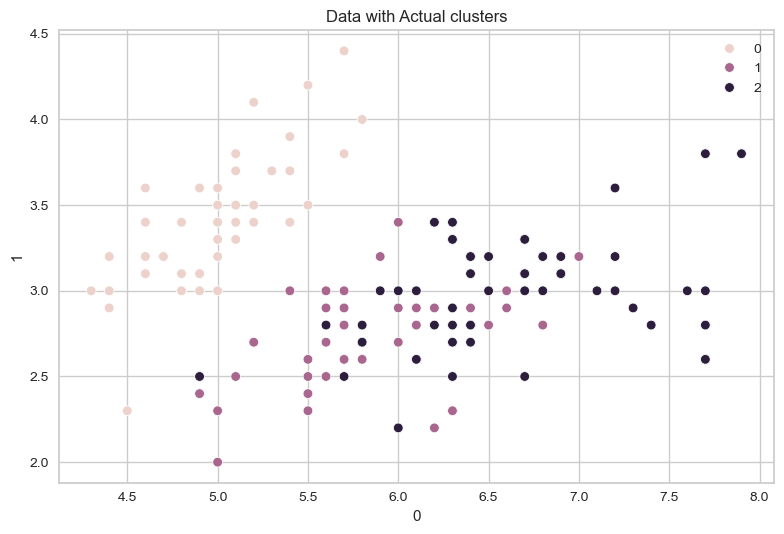

In [35]:
sns.scatterplot(
    x = X.iloc[:,0],
    y = X.iloc[:,1],
    hue = y
)
plt.title("Data with Actual clusters")
plt.tight_layout()

## <u>**1. K-means**</u>

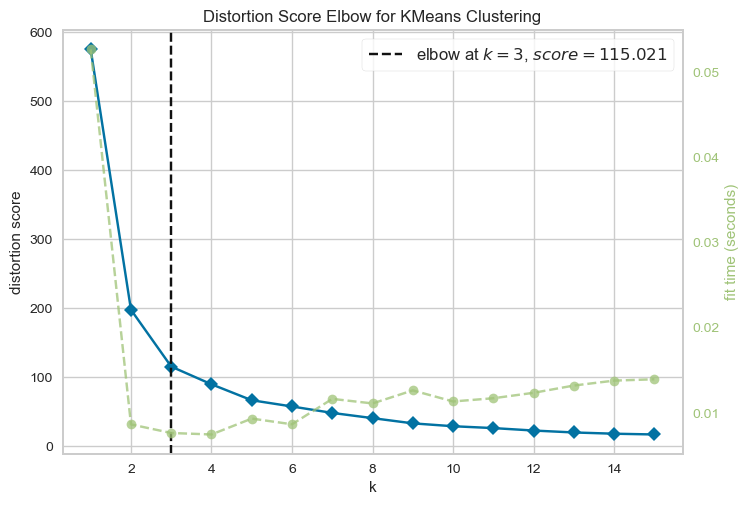

In [57]:
# finding value for k 
visualizer = KElbowVisualizer(
    KMeans(random_state = 42, n_init = 10),
    k = (1,16)
)

visualizer.fit(X_scaled_pca)
visualizer.finalize()         # confirmed that k = 3

kmeans = KMeans(random_state = 42, n_init = 10, n_clusters = 3)
labels_km = kmeans.fit_predict(X_scaled_pca)

## <u>**2. DBSCAN**</u>


In [56]:
# there is no random state in DBSCAN as it is a deterministic algorithm that relies on fixed spatial neighborhoods and 
# database point orders rather than random initializations
dbsc = DBSCAN(
    eps = 0.5,
    min_samples = 5
)

labels_db = dbsc.fit_predict(X_scaled_pca)

labels_db

# DBSCAN Predicted only 2 classes 0 and 1, -1 is for anomalies i.e. its not a class but our dataset has 

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

### <u>Visualise results</u>

Text(0.5, 1.0, 'Predicted clusters (DBSCAN)')

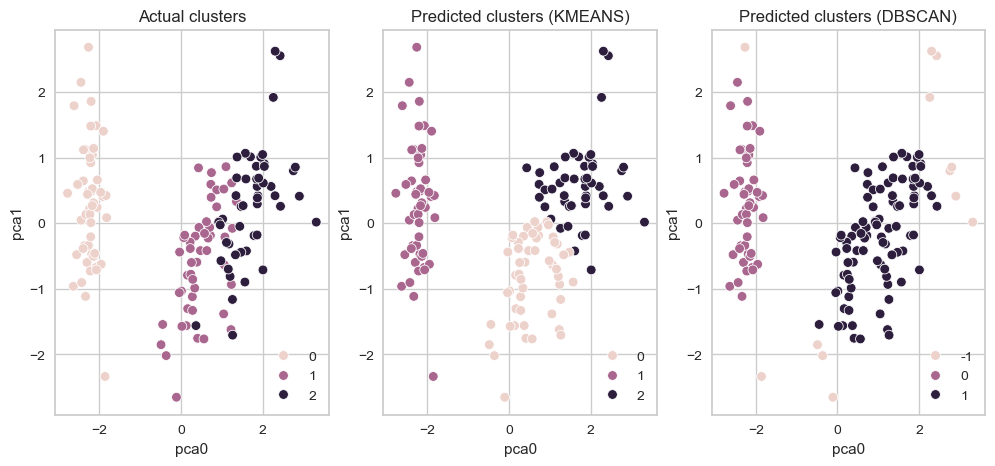

In [58]:
# define figure
fig,ax = plt.subplots(1,3,figsize = (12,5))

# plot the graphs
sns.scatterplot(ax = ax[0],
                x=X_scaled_pca.iloc[:, 0],
                y=X_scaled_pca.iloc[:, 1],
                hue=y
)
sns.scatterplot(ax = ax[1],
                x=X_scaled_pca.iloc[:, 0],
                y=X_scaled_pca.iloc[:, 1],
                hue=labels_km
)

sns.scatterplot(ax = ax[2],
                x=X_scaled_pca.iloc[:, 0],
                y=X_scaled_pca.iloc[:, 1],
                hue=labels_db
)

# put title on each graph
ax[0].set_title("Actual clusters")
ax[1].set_title("Predicted clusters (KMEANS)") # has proper 3 classes and pretty close to labels
ax[2].set_title("Predicted clusters (DBSCAN)") # predicted only 2 classes with a lot of anomalies

---
# Non-Linear Data
- Now we will see the real power of DBSCAN

### <u>Make Dataset</u>

In [72]:
# to make non linear dataset, we use make_moons functions
# it always gives a 2d data so need to use pca, but we need to scale

X, y = make_moons(
    n_samples=10000,
    noise=0.05,
    random_state=42
)

### <u>Scale Data</u>

In [73]:
# use the standard scaler we already make above
X_scaled = scaler.fit_transform(X)

X_scaled.head()

,x0,x1
0,-0.145132,-0.839681
1,-1.548291,-0.263556
2,-0.070875,1.186836
3,-1.644185,-0.201482
4,-1.667504,0.156944


### <u>Visualise the Data</u>

<Axes: xlabel='x0', ylabel='x1'>

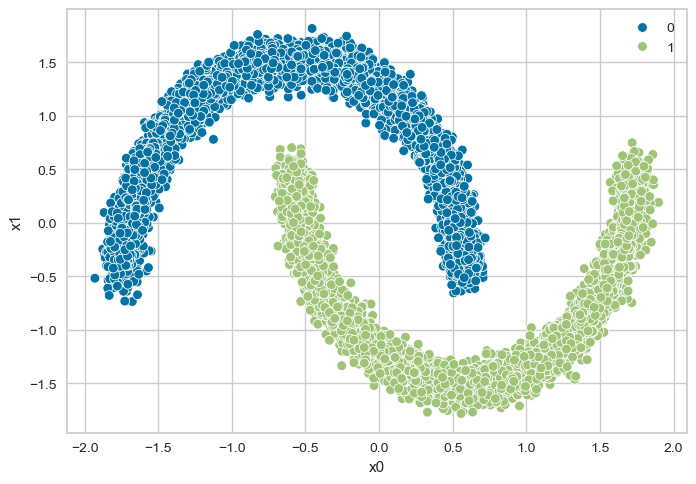

In [75]:
sns.scatterplot(
    x = X_scaled.iloc[:,0],
    y = X_scaled.iloc[:,1],
    hue = y
)

## <u>**1. K-means**</u>

In [76]:
kmeans = KMeans(
    n_init = 10,
    random_state = 42,
    n_clusters = 2
)
labels_km = kmeans.fit_predict(X_scaled)

## <u>**2. DBSCAN**</u>

In [107]:
dbsc = DBSCAN(
    eps = 0.25,
    min_samples = 5
)

labels_db = dbsc.fit_predict(X_scaled)

### <u>Visualise results</u>

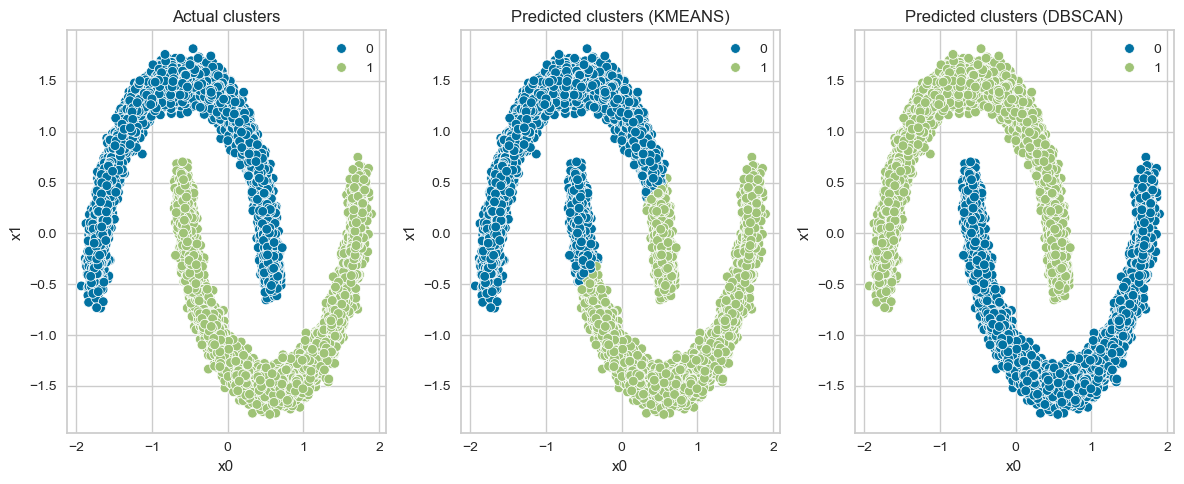

In [108]:
# define figure
fig,ax = plt.subplots(1,3,figsize = (12,5))

# plot the graphs
sns.scatterplot(ax = ax[0],
                x=X_scaled.iloc[:, 0],
                y=X_scaled.iloc[:, 1],
                hue=y
)
sns.scatterplot(ax = ax[1],
                x=X_scaled.iloc[:, 0],
                y=X_scaled.iloc[:, 1],
                hue=labels_km
)

sns.scatterplot(ax = ax[2],
                x=X_scaled.iloc[:, 0],
                y=X_scaled.iloc[:, 1],
                hue=labels_db
)

# put title on each graph
ax[0].set_title("Actual clusters")
ax[1].set_title("Predicted clusters (KMEANS)") # has proper 3 classes and pretty close to labels
ax[2].set_title("Predicted clusters (DBSCAN)") # predicted only 2 classes with a lot of anomalies
plt.tight_layout()

### Findings :-
1. Kmeans drew a straight line across the dataset and divided into 2 parts but its a non linear data the clustering is not good
2. DBSCAN perfectly clustered and is identical to the actual clusters showing its power on non-linear data